In [2]:
from itertools import chain, product

import sympy as sp
from sympy.abc import c, epsilon, mu, omega, t, x, y, z
from sympy.solvers.ode.systems import dsolve_system
from sympy.vector import CoordSys3D, Del

import numpy as np
from scipy.optimize import bisect

#from preview_wrappers import preview_collection, save_latex_as_image
#from solveHomoSLAE import solve_all


def gen_vars_subs(U_symbols, args_before, args_after):
    return {
        U(*args_before): U(*args_after) for U in list(chain.from_iterable(U_symbols))
    }


def gen_subs_diff(R, U_comps):
    return {
        value.diff(key): 0
        for key, value in list(product([R.y, R.z], list(U_comps.components.values())))
    }


def list_subs(eqs: list, subs: dict, eval=True):
    if eval is True:
        return list(map(lambda eq: eq.subs(subs).expand().simplify(), eqs))
    else:
        return list(map(lambda eq: eq.subs(subs), eqs))


def check_sols(eqs, sols):
    sols_subs = {sol.lhs: sol.rhs for sol in sols}
    return list_subs(eqs, sols_subs)


def gen_vector_field_symbols(R, order=0):
    E_symbols = [
        [sp.Function(f"E^{comp}_{i}") for comp in [x, y, z]] for i in range(order + 1)
    ]
    E_vec_comps = [
        Ex(R.x, R.y, R.z) * R.i + Ey(R.x, R.y, R.z) * R.j + Ez(R.x, R.y, R.z) * R.k
        for Ex, Ey, Ez in E_symbols
    ]
    H_symbols = [
        [sp.Function(f"H^{comp}_{i}") for comp in [x, y, z]] for i in range(order + 1)
    ]
    H_vec_comps = [
        Hx(R.x, R.y, R.z) * R.i + Hy(R.x, R.y, R.z) * R.j + Hz(R.x, R.y, R.z) * R.k
        for Hx, Hy, Hz in H_symbols
    ]
    E_asympt = [
        sum(
            map(
                lambda k, vec: vec / (sp.I * omega) ** k,
                range(s + 1),
                E_vec_comps,
            ),
            0 * R.i,
        )
        for s in range(order + 1)
    ]  # 0*R.i determines return type
    H_asympt = [
        sum(
            map(
                lambda k, vec: vec / (sp.I * omega) ** k,
                range(s + 1),
                H_vec_comps,
            ),
            0 * R.i,
        )
        for s in range(order + 1)
    ]
    return E_symbols, H_symbols, E_vec_comps, H_vec_comps, E_asympt, H_asympt


def gen_maxwell_eqs(
    R,
    delop,
    phi,
    E_symbols,
    H_symbols,
    E_vec_comps,
    H_vec_comps,
    E_asympt,
    H_asympt,
    order=0,
    prev_order_eqs=None,
):
    curl_E = (
        (
            (
                delop.cross(
                    E_asympt[order]
                    * sp.exp(sp.I * omega * t - sp.I * omega / c * phi(R.z))
                )
                + mu
                / c
                * (
                    H_asympt[order]
                    * sp.exp(sp.I * omega * t - sp.I * omega / c * phi(R.z))
                ).diff(t)
            )
            .doit()
            .to_matrix(R)
            / sp.exp(sp.I * omega * t - sp.I * omega / c * phi(R.z))
        )
        .expand()
        .subs(gen_subs_diff(R, E_vec_comps[order]))
    )

    curl_H = (
        (
            (
                delop.cross(
                    H_asympt[order]
                    * sp.exp(sp.I * omega * t - sp.I * omega / c * phi(R.z))
                )
                - epsilon
                / c
                * (
                    E_asympt[order]
                    * sp.exp(sp.I * omega * t - sp.I * omega / c * phi(R.z))
                ).diff(t)
            )
            .doit()
            .to_matrix(R)
            / sp.exp(sp.I * omega * t - sp.I * omega / c * phi(R.z))
        )
        .expand()
        .subs(gen_subs_diff(R, H_vec_comps[order]))
    )

    maxwell_eqs = list_subs(
        [sp.Eq(eq, 0) for eq in list(curl_E) + list(curl_H)],
        {R.x: x, R.y: y, R.z: z},
        eval=False,
    )

    if prev_order_eqs is not None:
        maxwell_eqs = [
            sp.Eq((maxwell_eqs[i].lhs - prev_order_eqs[i].lhs).expand(), 0)
            for i in range(6)
        ]

    maxwell_alg_eqs = [
        sp.Eq(
            E_symbols[order][0](x, y, z),
            sp.solve(maxwell_eqs[3], E_symbols[order][0](x, y, z))[0],
        ),
        sp.Eq(
            H_symbols[order][0](x, y, z),
            sp.solve(maxwell_eqs[0], H_symbols[order][0](x, y, z))[0],
        ),
    ]

    maxwell_diff_eqs = list(
        filter(
            lambda x: x is not (sp.sympify(True) or 0),
            list_subs(maxwell_eqs, {eq.lhs: eq.rhs for eq in maxwell_alg_eqs}),
        )
    )
    return maxwell_eqs, maxwell_alg_eqs, maxwell_diff_eqs


def layered_sols(sols, layer_symbol, order) -> list:
    # TODO: add a param to signal what exponents (with `+` or `-`) to omit
    # WARNING: order of substituting symbols here is "hard-coded" for author's convenience
    if order > 0:
        prev_U_subs = {
            sp.Function("E^x_0")(x, z): sp.Function(f"E^{{x,{layer_symbol}}}_{0}")(
                x, z
            ),
            sp.Function("E^y_0")(x, z): sp.Function(f"E^{{y,{layer_symbol}}}_{0}")(
                x, z
            ),
            sp.Function("E^z_0")(x, z): sp.Function(f"E^{{z,{layer_symbol}}}_{0}")(
                x, z
            ),
            sp.Function("H^x_0")(x, z): sp.Function(f"H^{{x,{layer_symbol}}}_{0}")(
                x, z
            ),
            sp.Function("H^y_0")(x, z): sp.Function(f"H^{{y,{layer_symbol}}}_{0}")(
                x, z
            ),
            sp.Function("H^z_0")(x, z): sp.Function(f"H^{{z,{layer_symbol}}}_{0}")(
                x, z
            ),
        }
    else:
        prev_U_subs = dict()

    U_p_subs = {
        sp.Function(f"{U}^{{{i}}}_p")(x, z): sp.Function(
            f"{U}^{{{i},{layer_symbol}}}_p"
        )(x, z)
        for U, i in product(["E", "H"], [x, y, z])
    }

    match layer_symbol:
        case "c":
            # x -> x - h(z) eases calculation (only for 0-order for now)
            if order == 0:
                sols = [
                    sol.replace(
                        sp.exp,
                        lambda arg: sp.exp(arg.subs({x: x - sp.Function("h_l")(z)})),
                    )
                    for sol in sols
                ]

            sols = list_subs(
                sols,
                {
                    sp.Symbol("C1"): sp.Symbol(f"A_{order}^{layer_symbol}"),
                    sp.Symbol("C2"): 0,
                    sp.Symbol("C3"): sp.Symbol(f"B_{order}^{layer_symbol}"),
                    sp.Symbol("C4"): 0,
                }
                | prev_U_subs
                | U_p_subs,
                eval=False,
            )

        case "l":
            if order == 0:
                sols = [
                    sol.replace(
                        sp.exp,
                        lambda arg: sp.exp(arg.subs({x: x - sp.Function("h_f")(z)})),
                    )
                    for sol in sols
                ]

            sols = list_subs(
                sols,
                {
                    sp.Symbol("C1"): sp.Symbol(f"A_{order}^{layer_symbol}"),
                    sp.Symbol("C2"): sp.Symbol(f"B_{order}^{layer_symbol}"),
                    sp.Symbol("C3"): sp.Symbol(f"C_{order}^{layer_symbol}"),
                    sp.Symbol("C4"): sp.Symbol(f"D_{order}^{layer_symbol}"),
                }
                | prev_U_subs
                | U_p_subs,
                eval=False,
            )


        case "f":
            sols = list_subs(
                sols,
                {
                    sp.Symbol("C1"): sp.Symbol(f"A_{order}^{layer_symbol}"),
                    sp.Symbol("C2"): sp.Symbol(f"B_{order}^{layer_symbol}"),
                    sp.Symbol("C3"): sp.Symbol(f"C_{order}^{layer_symbol}"),
                    sp.Symbol("C4"): sp.Symbol(f"D_{order}^{layer_symbol}"),
                }
                | prev_U_subs
                | U_p_subs,
                eval=False,
            )

        case "s":
            sols = list_subs(
                sols,
                {
                    sp.Symbol("C1"): 0,
                    sp.Symbol("C2"): sp.Symbol(f"A_{order}^{layer_symbol}"),
                    sp.Symbol("C3"): 0,
                    sp.Symbol("C4"): sp.Symbol(f"B_{order}^{layer_symbol}"),
                }
                | prev_U_subs
                | U_p_subs,
                eval=False,
            )

    return [
        sol.xreplace(
            {
                sol.lhs: comp,
                epsilon: sp.Symbol(f"epsilon_{layer_symbol}"),
                mu: sp.Symbol(f"mu_{layer_symbol}"),
                sp.Function("eta")(z): sp.Function(f"eta_{layer_symbol}")(z),
                sp.Function("gamma")(z): sp.Function(f"gamma_{layer_symbol}")(z),
                sp.Function("gammatilde")(z): sp.Function(f"gammatilde_{layer_symbol}")(
                    z
                ),
            }
        )
        for sol, comp in zip(
            sols,
            [
                sp.Function(f"E^{{x,{layer_symbol}}}_{order}")(x),
                sp.Function(f"E^{{y,{layer_symbol}}}_{order}")(x),
                sp.Function(f"E^{{z,{layer_symbol}}}_{order}")(x), 
               sp.Function(f"H^{{x,{layer_symbol}}}_{order}")(x),
                sp.Function(f"H^{{y,{layer_symbol}}}_{order}")(x),
                sp.Function(f"H^{{z,{layer_symbol}}}_{order}")(x),
            ],
        )
    ]


def gen_boundry_conds(R, delop, U, border_func, border_func_value, layers, order):
    normal = delop(border_func).doit()
    char_U = str(list(U.components.values())[0])[0]
    nU_1 = normal.cross(U).subs(
        {
            U.components[R.i]: sp.Function(f"{char_U}^{{x,{layers[0]}}}_{order}")(x),
            U.components[R.j]: sp.Function(f"{char_U}^{{y,{layers[0]}}}_{order}")(x),
            U.components[R.k]: sp.Function(f"{char_U}^{{z,{layers[0]}}}_{order}")(x),
        }
    )

    nU_2 = normal.cross(U).subs(
        {
            U.components[R.i]: sp.Function(f"{char_U}^{{x,{layers[1]}}}_{order}")(x),
            U.components[R.j]: sp.Function(f"{char_U}^{{y,{layers[1]}}}_{order}")(x),
            U.components[R.k]: sp.Function(f"{char_U}^{{z,{layers[1]}}}_{order}")(x),
        }
    )

    boundry_eqs = (nU_1 - nU_2).subs({x: border_func_value, R.y: y, R.z: z})

    return [sp.Eq(boundry_eqs.components[arg], 0) for arg in [R.j, R.k]]


def boundry_check_all_solutions(eqs, vars, all_sols):
    """
    we need to show, that equation is True or is a multiple of Determinant
    ref: https://doi.org/10.1134/S0361768822020049
    """
    M, b = sp.linear_eq_to_matrix(eqs, vars)

    if b != sp.zeros(len(vars), 1):
        raise ValueError("`eqs` must be a homogeneous system")

    eqs_lhs = [eq.lhs - eq.rhs for eq in eqs]

    det = M.det(method="berkowitz").expand().combsimp()

    for i, sol in enumerate(all_sols):
        system = list_subs(eqs_lhs, sol, eval=False)
        system = [
            eq.expand()
            .combsimp()
            .subs({det: sp.Symbol("|M|"), -det: -sp.Symbol("|M|")})
            for eq in system
        ]

        print(f"for solution {i+1}:")
        for eq in system:
            if eq == 0:
                print("\tOK")
            elif eq.has(sp.Symbol("|M|")):
                print("\tOK (has det(M))")
        # preview_collection(system)


def add_layer_index(symbol, layer):
    if symbol.is_Function:
        return sp.Function(f'{symbol.name}_{layer}')
    if symbol.is_Symbol:        
        return sp.Symbol(f'{symbol.name}_{layer}')


if __name__ == "__main__":
    # setup sympy symbols
    R = CoordSys3D("")
    delop = Del()  # nabla
    phi = sp.Function("phi")
    eta = sp.Function("eta")
    gamma = sp.Function("gamma")
    max_order = 1  # order of expansion
    E_symbols, H_symbols, E_vec_comps, H_vec_comps, E_asympt, H_asympt = (
        gen_vector_field_symbols(R, order=max_order)
    )

    # contsruct Maxwell's equations
    eqs_0, alg_eqs_0, diff_eqs_0 = gen_maxwell_eqs(
        R,
        delop,
        phi,
        E_symbols,
        H_symbols,
        E_vec_comps,
        H_vec_comps,
        E_asympt,
        H_asympt,
        order=0,
    )
    eqs_0 = list_subs(
        eqs_0, gen_vars_subs([E_symbols[0], H_symbols[0]], [x, y, z], [x])
    )
    alg_eqs_0 = list_subs(
        alg_eqs_0, gen_vars_subs([E_symbols[0], H_symbols[0]], [x, y, z], [x])
    )
    diff_eqs_0 = list_subs(
        diff_eqs_0, gen_vars_subs([E_symbols[0], H_symbols[0]], [x, y, z], [x])
    )

    # solve ODE system
    diff_sols_0 = dsolve_system(
        diff_eqs_0,
        funcs=[
            E_symbols[0][1](x),
            E_symbols[0][2](x),
            H_symbols[0][1](x),
            H_symbols[0][2](x),
        ],
        t=x,
    )[0]

    assert check_sols(diff_eqs_0, diff_sols_0) == [True, True, True, True]
    print("0: Found and checked solution to zero-order method")

    sols_0 = [
        alg_eqs_0[0].subs({eq.lhs: eq.rhs for eq in diff_sols_0}),
        diff_sols_0[0],
        diff_sols_0[1],
        alg_eqs_0[1].subs({eq.lhs: eq.rhs for eq in diff_sols_0}),
        diff_sols_0[2],
        diff_sols_0[3],
    ]

    sols_0 = list_subs(
        sols_0,
        {
            omega / c * sp.sqrt(-epsilon * mu + sp.diff(phi(z), z) ** 2): gamma(z),
            -epsilon * mu + sp.diff(phi(z), z) ** 2: eta(z),
        },
        eval=False,
    )

    # remove denominator to shorten expressions
    sols_0 = list_subs(
        sols_0,
        {
            sp.Symbol("C1"): sp.Symbol("C1") * sp.sqrt(eta(z)),
            sp.Symbol("C2"): sp.Symbol("C2") * sp.sqrt(eta(z)),
            sp.Symbol("C3"): sp.Symbol("C3") * epsilon,
            sp.Symbol("C4"): sp.Symbol("C4") * epsilon,
        },
        eval=False,
    )

    #save_latex_as_image(sols_0, "general_solution_zero_order")

    # Construct solutions for different layers
    sols_0_layers = {
        layer: layered_sols(sols_0, layer, order=0) for layer in ["c", "l", "f", "s"]
    }

    # Now solving for 2D waveguide with smoothly irregular transition, x=h(z)

    # boundry conditions

    # for 4 layer slab waveguide:
    #     cover
    #     ---- x=h_l=h_f+dh
    #     lens
    #     ---- x=h_f
    #     film
    #     ---- x=0
    #     substrate

    
    h_l = sp.Function("h_l")
    h_f = sp.Function("h_f")    
    border_func = lambda f: R.x - f(R.z)

    E_boundry_cl_0 = gen_boundry_conds(
        R, delop, E_vec_comps[0], border_func(h_l), h_l(z), ["c", "l"], order=0
    )

    H_boundry_cl_0 = gen_boundry_conds(
        R, delop, H_vec_comps[0], border_func(h_l), h_l(z), ["c", "l"], order=0
    )

    E_boundry_lf_0 = gen_boundry_conds(
        R, delop, E_vec_comps[0], border_func(h_f), h_f(z), ["l", "f"], order=0
    )

    H_boundry_lf_0 = gen_boundry_conds(
        R, delop, H_vec_comps[0], border_func(h_f), h_f(z), ["l", "f"], order=0
    )

    E_boundry_fs_0 = gen_boundry_conds(
        R, delop, E_vec_comps[0], border_func(h_f), 0, ["f", "s"], order=0
    )

    H_boundry_fs_0 = gen_boundry_conds(
        R, delop, H_vec_comps[0], border_func(h_f), 0, ["f", "s"], order=0
    )

    boundry_eqs_0 = list_subs(
        E_boundry_cl_0 + H_boundry_cl_0 + E_boundry_lf_0 + H_boundry_lf_0 + E_boundry_fs_0 + H_boundry_fs_0,
        {
            eq.lhs: eq.rhs
            for eq in list_subs(sols_0_layers["c"] + sols_0_layers["l"], {x: h_l(z)}, eval=False)
            +list_subs(sols_0_layers["l"] + sols_0_layers["f"], {x: h_f(z)}, eval=False)
            +list_subs(sols_0_layers["f"] + sols_0_layers["s"], {x: 0}, eval=False)

        },
        eval=False,
    )

    # order is intentional to produce block-diagonal matrix
    sym_coeffs_0 = [
        # TE
        sp.Symbol("A_0^c"),
        sp.Symbol("A_0^l"),
        sp.Symbol("B_0^l"),
        sp.Symbol("A_0^f"),
        sp.Symbol("B_0^f"),
        sp.Symbol("A_0^s"),

        # TM
        sp.Symbol("B_0^c"),
        sp.Symbol("C_0^l"),
        sp.Symbol("D_0^l"),
        sp.Symbol("C_0^f"),
        sp.Symbol("D_0^f"),
        sp.Symbol("B_0^s"),
    ]

    # reorder equations to block-diagonal matrix of coefficients
    # new_ord = [1, 2, 5, 6, 0, 3, 4, 7]
    new_order = [1, 2, 5, 6, 10, 9, 0, 3, 4, 7, 8, 11]
    boundry_eqs_0 = [boundry_eqs_0[i] for i in new_order]
    M_0, _ = sp.linear_eq_to_matrix(boundry_eqs_0, sym_coeffs_0)



    M_0_TE = M_0[:6, :6]
    sym_coeffs_0_TE = sym_coeffs_0[:6]

    # eqs_0_TE = [
    #     sp.Eq(eq.collect(sym_coeffs_0_TE, sp.combsimp), 0)
    #     for eq in M_0_TE * sp.matrices.Matrix(sym_coeffs_0_TE)
    # ]

    # sol_coeffs_0_TE = solve_all(eqs_0_TE, sym_coeffs_0_TE)

    # sol_coeffs_0_TE = [
    #     {
    #         coeff: expr.expand().collect(sp.exp(sp.Wild("w")), sp.simplify)
    #         for coeff, expr in sol.items()
    #     }
    #     for sol in sol_coeffs_0_TE
    # ]
    # print(f"0: found coefficients for TE-mode:{sym_coeffs_0_TE}")
    # save_latex_as_image(sol_coeffs_0_TE, "coeffs_0_TE_all")
    
    # boundry_check_all_solutions(eqs_0_TE, sym_coeffs_0_TE, sol_coeffs_0_TE)
    # print("0: check all variants of the solutions to boundry equations TE mode")

    M_0_TM = M_0[6:, 6:]
    sym_coeffs_0_TM = sym_coeffs_0[6:]
    # eqs_0_TM = [
    #     sp.Eq(eq.collect(sym_coeffs_0_TM, sp.combsimp), 0)
    #     for eq in M_0_TM * sp.matrices.Matrix(sym_coeffs_0_TM)
    # ]

    # sol_coeffs_0_TM = solve_all(eqs_0_TM, sym_coeffs_0_TM)

    # sol_coeffs_0_TM = [
    #     {
    #         coeff: expr.expand().collect(sp.exp(sp.Wild("w")), sp.combsimp)
    #         for coeff, expr in sol.items()
    #     }
    #     for sol in sol_coeffs_0_TM
    # ]

    # print(f"0: found coefficients for TM-mode:{sym_coeffs_0_TM}")

    # NOTE: unable to finish with default algortims. Manually checked for 3rd
    # and 4th sets.
    # bouindry_check_all_solutions(eqs_0_TM, sym_coeffs_0_TM, sol_coeffs_0_TM)
    # print("0: check all variants of the solutions to boundry equations TM mode")

    # save_latex_as_image(sol_coeffs_0_TM, "coeffs_0_TM_all")

    # Численный расчет
    layers = ['c', 'f', 'l', 's']
    symbolic_subs = dict()
    for layer in layers:
        epsilon_layer = add_layer_index(epsilon, layer)
        mu_layer = add_layer_index(mu, layer)        
        symbolic_subs[add_layer_index(eta, layer)(z)] = -epsilon_layer * mu_layer + sp.diff(phi(z), z) ** 2
        symbolic_subs[add_layer_index(gamma, layer)(z)] = omega / c * sp.sqrt(-epsilon_layer * mu_layer + sp.diff(phi(z), z) ** 2)

    num_lambda = sp.sympify(0.55)
    beta = sp.Symbol('beta')
    dh = sp.Symbol(r'\delta h') # это ищем
    
    numeric_parameters = {sp.Symbol('epsilon_c')  : sp.sympify(1.0)**2,
                           sp.Symbol('epsilon_l') : sp.sympify(3.61),
                           sp.Symbol('epsilon_f') : sp.sympify(1.565)**2,
                           sp.Symbol('epsilon_s') : sp.sympify(1.47)**2,
                           h_f(z)                 : 2*num_lambda,
                           h_l(z)                 : 2*num_lambda+dh,  # форма линзы h_l=h_f+dh
                           sp.Symbol('mu_c')      : sp.sympify(1.0),
                           sp.Symbol('mu_l')      : sp.sympify(1.0),
                           sp.Symbol('mu_f')      : sp.sympify(1.0),
                           sp.Symbol('mu_s')      : sp.sympify(1.0),
                           omega/c                : 2*sp.pi/num_lambda,
                           sp.diff(phi(z),z)**2   : beta**2,
                           }
    
   

0: Found and checked solution to zero-order method


In [187]:
dh = sp.Symbol(r'dh', Float=True)
beta = sp.Symbol('beta', complex=True)
numeric_parameters = {sp.Symbol('epsilon_c')  : sp.sympify(1.0)**2,
                           sp.Symbol('epsilon_l') : sp.sympify(3.61),
                           sp.Symbol('epsilon_f') : sp.sympify(1.565)**2,
                           sp.Symbol('epsilon_s') : sp.sympify(1.47)**2,
                           h_f(z)                 : 2*num_lambda,
                           h_l(z)                 : 2*num_lambda+dh,  # форма линзы h_l=h_f+dh
                           sp.Symbol('mu_c')      : sp.sympify(1.0),
                           sp.Symbol('mu_l')      : sp.sympify(1.0),
                           sp.Symbol('mu_f')      : sp.sympify(1.0),
                           sp.Symbol('mu_s')      : sp.sympify(1.0),
                           omega/c                : 2*sp.pi/num_lambda,
                           sp.diff(phi(z),z)**2   : beta**2,
                           }

In [181]:
dh.is_real

True

In [3]:
M_0_TE_num_inter = sp.lambdify([beta, dh], M_0_TE.subs(symbolic_subs).subs(numeric_parameters).doit(), 
                         modules=[{'sqrt':np.emath.sqrt},'numpy'])
def det_numerical_2(beta, dh):
    M = M_0_TE_num_inter(beta, dh)
    det = np.linalg.det(M)
    return det.imag+det.real

In [51]:
# к.ф.з. для трехслойного волновода -- на границе с линзой dh=0
beta_0 = bisect(lambda b: det_numerical_2(b, 0), 1.54, 1.6, xtol=1e-16)

In [59]:
with open("../src/IndexProf_2000_points.txt", 'r') as f:
    lines = f.readlines()[2:]
    data = []
    for line in lines:
        data.append(list(map(float,line.split())))

In [69]:
data = data[::-1]

In [130]:
data[-1]

[0.0, 1.1753112161847648]

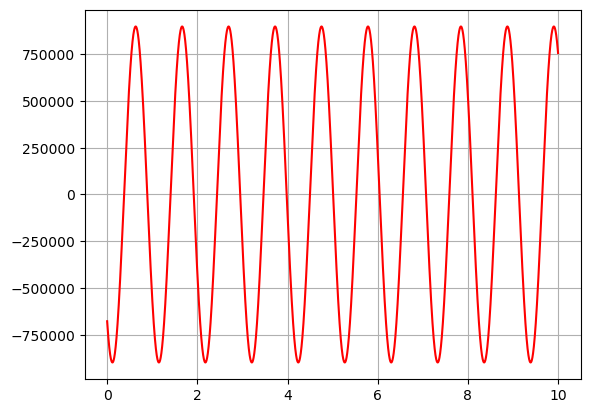

In [128]:
# import matplotlib.pyplot as plt
x = np.linspace(0,10,20000)
y1 = [det_numerical_2(beta_0*data[-1][1], xx) for xx in x]
# y2 = [det_numerical_2(beta_0*data[100][1], xx) for xx in x]
plt.grid(True)
# plt.ylim(-1,1)
plt.plot(x,y1, c='r')
# plt.scatter(x,y2, c='b')
# det_numerical_2(beta_0*data[0][1], 0)
# bisect(lambda h: det_numerical_2(beta_0*data[0][1], h), 0, 0.4, xtol=1e-16)

In [201]:
%%time
dh = [0.]
beta = [beta_0]
for i in range(1, len(data)):
    beta.append(beta_0*data[i][1]) # beta=beta_0*n_eff
    
#     print(det_numerical_2(beta[i], dh[i-1]), det_numerical_2(beta[i], dh[i-1]+.2))
    dh.append(bisect(lambda h: det_numerical_2(beta[i], h), dh[i-1], dh[i-1]+.2, xtol=1e-16))

CPU times: user 13.2 s, sys: 0 ns, total: 13.2 s
Wall time: 13.2 s


In [159]:
beta[0]

1.5514927380692891

In [140]:
bisect(lambda h: det_numerical_2(beta[i], h), dh[i-1], dh[i-1]+.2, xtol=1e-16), optimize.golden(lambda h: abs(det_numerical_2(beta[i], h)), brack=(dh[i-1], dh[i-1]+.2), tol=1e-16)

(0.12176833699959771, np.float64(0.12176833699959763))

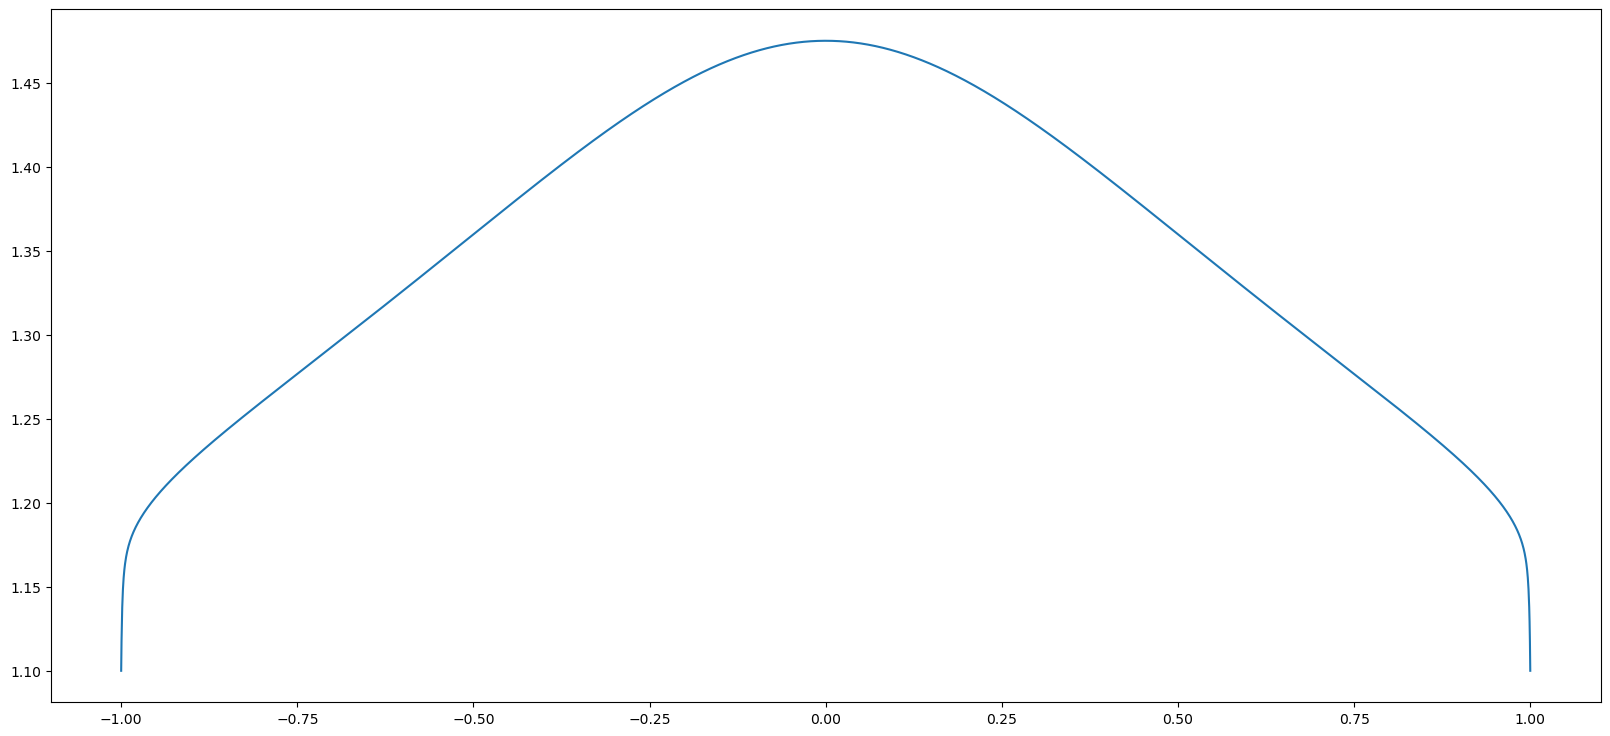

In [153]:
plt.figure(figsize=(20,9))
plt.plot(np.linspace(-1,1, len(dh)*2), list(map(lambda dh: dh+2*num_lambda, dh+dh[::-1])))


In [122]:
1.1+dh[-1]

1.4749934497999013

In [155]:
for i in range(len(data)):
    print(f'{data[i][0]},{data[i][1]},{dh[i]},{beta[i]}\n')
    break

1.0,1.0,0.0,1.5514927380692891



In [156]:
with open('luneberg_lens_numbers.txt', 'w') as f:
    f.write('r, n(r,f), dh, beta\n')
    for i in range(len(data)):
        f.write(f'{data[i][0]},{data[i][1]},{dh[i]},{beta[i]}\n')
    
    

### тестируем f2py backend

In [188]:
M_0_TE.subs(symbolic_subs).subs(numeric_parameters).doit()

Matrix([
[               1.0*I,                                    -1.0*I*exp(-6.90909090909091*pi*dh*sqrt(0.277008310249307*beta**2 - 1.0)),                                     1.0*I*exp(6.90909090909091*pi*dh*sqrt(0.277008310249307*beta**2 - 1.0)),                                                                                             0,                                                                                            0,                                          0],
[-sqrt(beta**2 - 1.0), 1.9*sqrt(0.277008310249307*beta**2 - 1.0)*exp(-6.90909090909091*pi*dh*sqrt(0.277008310249307*beta**2 - 1.0)), 1.9*sqrt(0.277008310249307*beta**2 - 1.0)*exp(6.90909090909091*pi*dh*sqrt(0.277008310249307*beta**2 - 1.0)),                                                                                             0,                                                                                            0,                                          0],
[                   0,                 

In [235]:
# M_0_TE_num_inter = sp.lambdify([beta, dh], M_0_TE.subs(symbolic_subs).subs(numeric_parameters).doit(), 
#                          modules=[{'sqrt':np.emath.sqrt},'numpy'])
# def det_numerical_2(beta, dh):
#     M = M_0_TE_num_inter(beta, dh)
#     det = np.linalg.det(M)
#     return det.imag+det.real

from sympy.utilities.autowrap import autowrap
from sympy.utilities.autowrap import ufuncify
sp.utilities.codegen.COMPLEX_ALLOWED = True
M_f2py = autowrap(M_0_TE.subs(symbolic_subs).subs(numeric_parameters).doit(), backend='f2py')
def det_numerical_f2py(beta, dh):
    M = M_f2py(beta, dh)
    det = np.linalg.det(M)
    return det.imag+det.real

In [200]:
%%time
dh_num_f2py = [0.]
beta_num_f2py = [beta_0]
for i in range(1, len(data)):
    beta_num_f2py.append(beta_0*data[i][1]) # beta=beta_0*n_eff
    
#     print(det_numerical_2(beta[i], dh[i-1]), det_numerical_2(beta[i], dh[i-1]+.2))
    dh_num_f2py.append(bisect(lambda h: det_numerical_f2py(beta_num_f2py[i], h), dh_num_f2py[i-1], dh_num_f2py[i-1]+.2, xtol=1e-16))

CPU times: user 482 ms, sys: 3.94 ms, total: 486 ms
Wall time: 485 ms


In [213]:
M_f2py_2 = autowrap(M_0_TE.subs(symbolic_subs).subs(numeric_parameters).doit().det(), backend='f2py')

SympifyError: SympifyError: "cannot sympify object of type <class 'function'>"

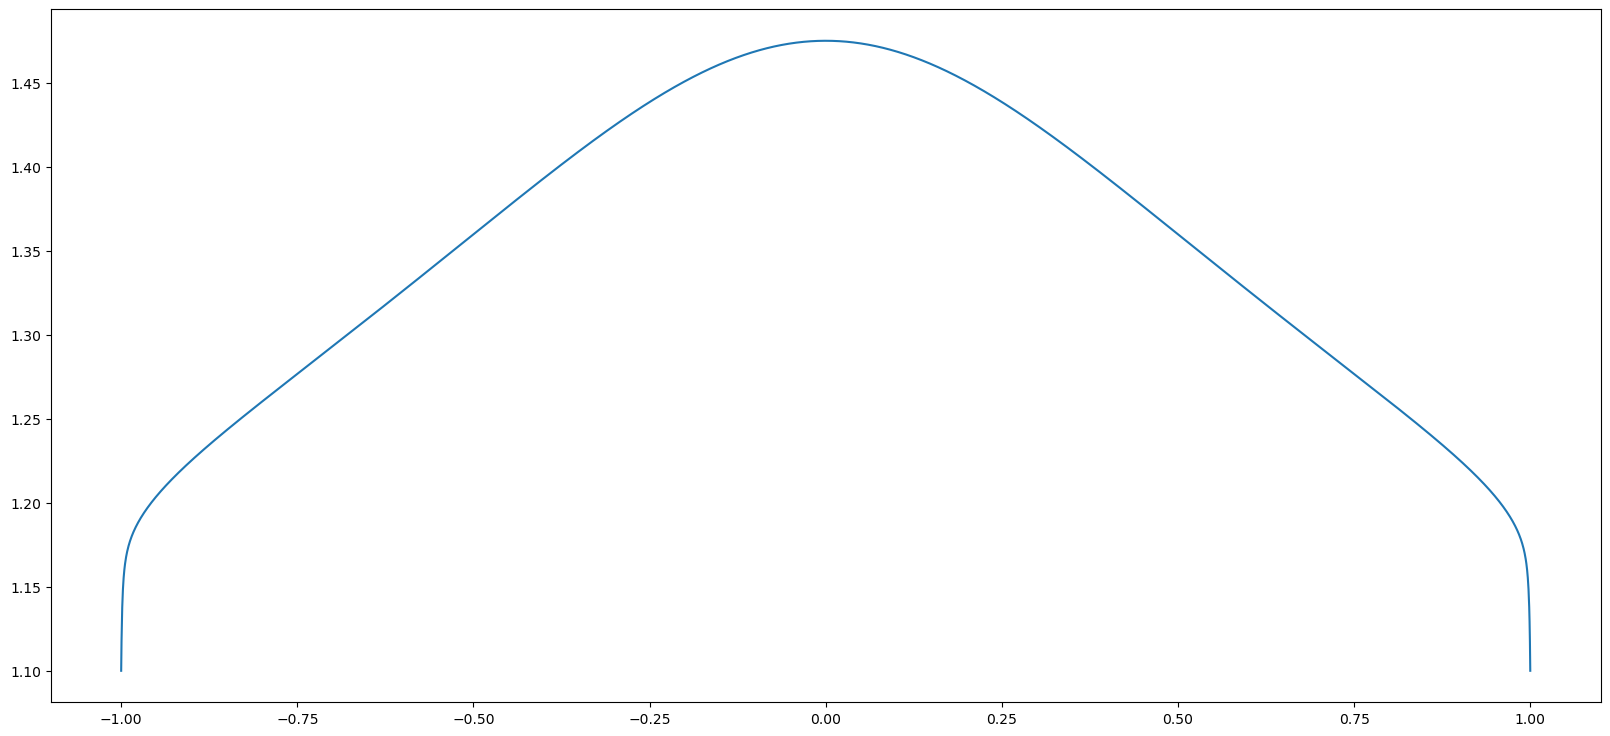

In [199]:
plt.figure(figsize=(20,9))
plt.plot(np.linspace(-1,1, len(dh_num)*2), list(map(lambda dh: dh+2*num_lambda, dh_num+dh_num[::-1])))


In [205]:
np.sum(np.array(dh_num)-np.array(dh_num_f2py))

np.float64(0.0)

In [206]:
13.2/0.485

27.216494845360824

In [210]:
%%timeit
det_numerical_f2py(beta_num_f2py[0], 0)

3.38 μs ± 30.9 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [211]:
%%timeit
det_numerical_2(beta_num_f2py[0], 0)

133 μs ± 1.06 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [212]:
133/3.38

39.349112426035504

In [224]:
abs(np.linalg.det(M_f2py(beta_0, 0)))

np.float64(3.008840166724842e-13)

In [229]:
def det_numerical_f2py_2(beta, dh):
    return abs(np.linalg.det(M_f2py(beta, dh)))

In [230]:
%%timeit
det_numerical_f2py_2(beta_num_f2py[0], 0)

3.14 μs ± 24.2 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [296]:
det_M_f2py = autowrap(M_0_TE.subs(symbolic_subs).subs(numeric_parameters).doit().to_DM().det(), backend='f2py')
def det_numerical_f2py_3(beta, dh):
    d = det_M_f2py(beta,dh)
    return d.real+d.imag

In [299]:
det_numerical_f2py_3(beta_num_f2py[0], 0.2)

0.5672930260646574

In [297]:
%%timeit
det_numerical_f2py_3(beta_num_f2py[0], 0)

285 ns ± 3.44 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [238]:
det_numerical_f2py(beta_num_f2py[0], 0)-det_numerical_f2py(beta_num_f2py[0], 0)

np.float64(0.0)

In [244]:
det_M_f2py_2 = autowrap(M_0_TE.subs(symbolic_subs).subs(numeric_parameters).doit().to_DM().det(), backend='f2py')
det_M_f2py_2(beta_num_f2py[1],dh_num[1])

(-1.5946761973833222e-15-3.9671509712309573e-16j)

In [245]:
t = det_M_f2py_2(beta_num_f2py[1],dh_num[1])

In [264]:
from sympy import I

t = 1.+I

In [286]:
t.together()

1.0 + I

In [308]:
det_M_f2py_3 = autowrap((abs(M_0_TE.subs(symbolic_subs).subs(numeric_parameters).doit().to_DM().det())), backend='f2py', tempdir='./tmp')

In [309]:
%%timeit
det_M_f2py_3(beta_num_f2py[0], 0)

254 ns ± 0.732 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [281]:
det_M_f2py_3(beta_num_f2py[0], 0)

AttributeError: 'complex' object has no attribute 'evalf'

In [304]:
%%time
dh_num_f2py = [0.]
beta_num_f2py = [beta_0]
for i in range(1, len(data)):
    beta_num_f2py.append(beta_0*data[i][1]) # beta=beta_0*n_eff
    
#     print(det_numerical_2(beta[i], dh[i-1]), det_numerical_2(beta[i], dh[i-1]+.2))
    dh_num_f2py.append(bisect(lambda h: det_numerical_f2py_3(beta_num_f2py[i], h), dh_num_f2py[i-1], dh_num_f2py[i-1]+.2, xtol=1e-16))
    
    
# plt.figure(figsize=(20,9))
# plt.plot(np.linspace(-1,1, len(dh_num)*2), list(map(lambda dh: dh+2*num_lambda, dh_num+dh_num[::-1])))


CPU times: user 139 ms, sys: 0 ns, total: 139 ms
Wall time: 139 ms


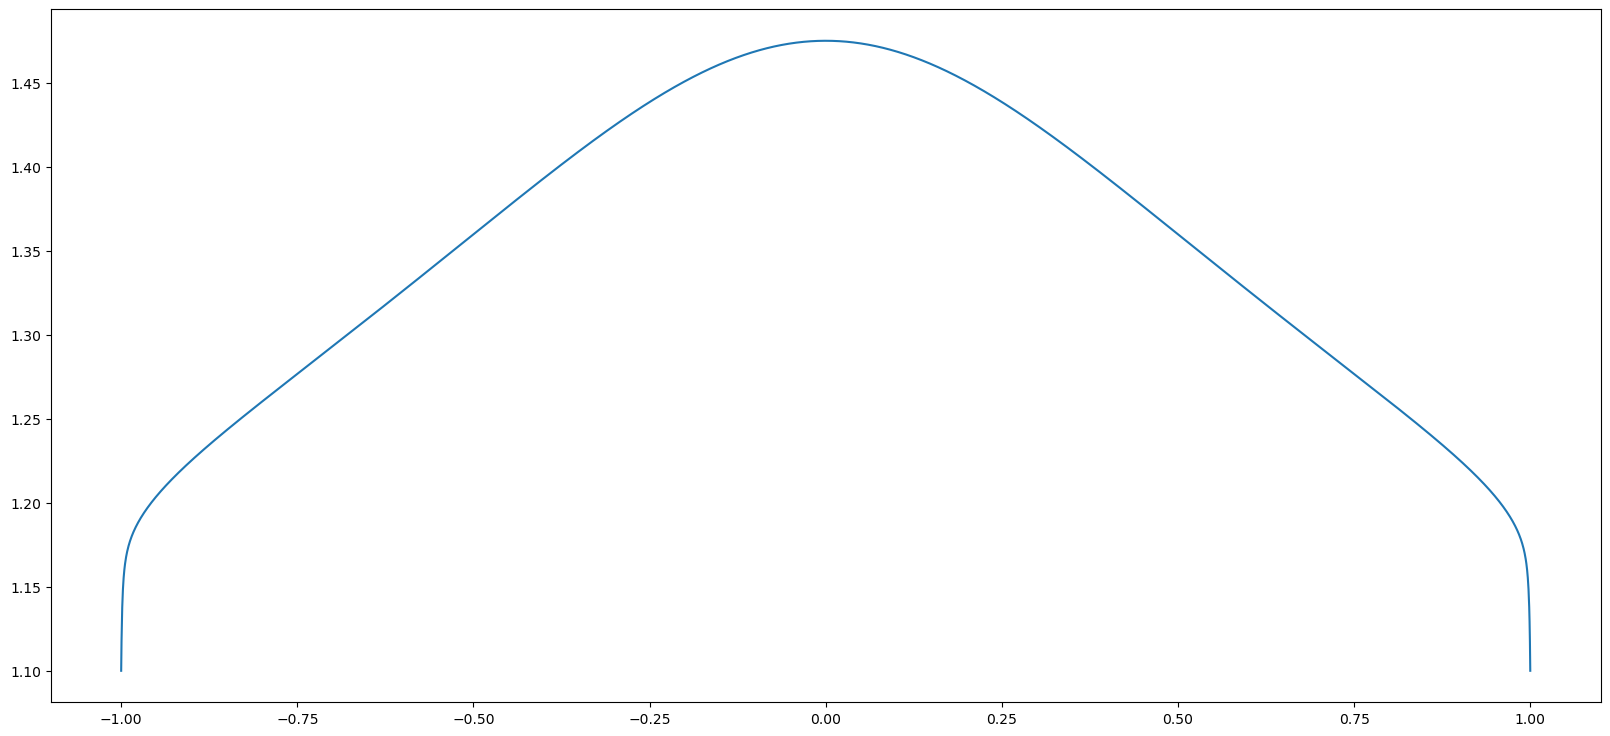

In [305]:
485/139

3.4892086330935252

In [307]:
3.38*1000/285

11.859649122807017